# Case: g.e30_a08l.GW_JRA.TL319_t232_wgx3_hycom1_N75.2026.sfc_test01

caseroot: /glade/work/chengz/cesm.cases/sfc_fluxes_check/g.e30_a08l.GW_JRA.TL319_t232_wgx3_hycom1_N75.2026.sfc_test01

# Purposes

Documenting the configuration.

<h1 align="center">MOM6 diagnostic boundary fluxes of scalars and their global budgets</h1> 

<div class="alert alert-info">
This notebook is meant to work with MOM6 run via the CESM framework
<div class="alert alert-info>

This notebook checks if the fluxes of water, heat, and salt crossing the surface of the ocean are consistent with corresponding changes in the ocean interior. This particular analysis is for g.e30_a08l.GW_JRA.TL319_t232_wgx3_hycom1_N75.2026.sfc_test01 CESM G_JRA-compset without OBCs.
      
Results from this notebook: 
1. Maps of surface boundary fluxes of water, heat, and salt crossing into the liquid seawater in MOM6;
2. Computation of self-consistency checks, including global heat, salt, and mass budgets to verify that the model is conserving scalars over the global/regional domain.   

Hopes for the use of this notebook: 
1. To provide a starting point to document boundary fluxes of scalar fields;
2. To teach MOM6 users about the boundary fluxes, their patterns, units, and sign conventions;
3. To perform self-consistency checks to ensure the model is conserving scalar fields;
4. To illustrate a self-contained notebook of use for MOM6 analysis.  

This notebook was originally developed at NOAA/GFDL, and it is provided freely to the MOM6 community. GFDL scientists developing MOM6 make extensive use of Python for diagnostics. We solicit modifications/fixes that are useful to the MOM6 community.

In [2]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np

In [3]:
path    = '/glade/u/home/chengz/scratch/g.e30_a08l.GW_JRA.TL319_t232_wgx3_hycom1_N75.2026.sfc_test01/run/'
static  = xr.open_dataset(path+'ocean.mom6.static.nc')
forcing = xr.open_dataset(path+'ocean.mom6.frc.0001.nc', decode_times=False)
surface = xr.open_dataset(path+'ocean.mom6.sfc.0001.nc', decode_times=False)

cp   = 3992.0
rho0 = 1035.0
n    = 3
print('Variables saved:')
for v in forcing.data_vars: print(v)
for v in surface.data_vars: print(v)
for v in static.data_vars: print(v)

Variables saved:
net_massin
net_massout
evap
seaice_melt
lrunoff
frunoff
lrunoff_glc
frunoff_glc
lprec
fprec
vprec
PRCmE
net_heat_surface
net_heat_coupler
LwLatSens
SW
frazil
seaice_melt_heat
Heat_PmE
heat_content_surfwater
heat_content_massin
heat_content_massout
heat_content_evap
heat_content_lprec
heat_content_fprec
heat_content_vprec
heat_content_lrunoff
heat_content_frunoff
heat_content_frunoff_glc
heat_content_lrunoff_glc
heat_content_cond
salt_flux
salt_flux_in
average_T1
average_T2
average_DT
time_bounds
SST
mass_wt
temp_int
salt_int
geolon
geolat
area_t
wet


In [4]:
# This section fills the fields used in this notebook.

#--------------------------------------------------------------
# geometric factors 
lon  = static['geolon']
lat  = static['geolat']
wet  = static['wet']
area = static['area_t'] * wet


#--------------------------------------------------------------
# time in seconds (time coordinate values are in days)
time = surface['time'].values * 86400.


#--------------------------------------------------------------
# sea surface temperature 
sst = surface['SST'].isel(time=n)


#--------------------------------------------------------------
# \int \rho \, dz \, (1,Theta,S), with \rho = \rho_{0} for Boussinesq.  
mass_wt = surface['mass_wt']
tomint  = surface['temp_int']
somint  = surface['salt_int']


#--------------------------------------------------------------
# mass flux of water crossing ocean surface [kg/(m^2 s)]
# positive values indicate mass entering ocean; 
# negative values indicate mass leaving ocean. 

# net mass flux entering ocean 
net_massin = forcing['net_massin'].isel(time=n)

# net mass flux leaving ocean
net_massout = forcing['net_massout'].isel(time=n)

# evaporation (negative) and condensation (positive)
evap = forcing['evap'].isel(time=n)

# meltw, fresh water from melting/forming sea ice
meltw = forcing['seaice_melt'].isel(time=n)

# liquid runoff entering ocean (non-negative)
lrunoff = forcing['lrunoff'].isel(time=n)

# frozen runoff entering ocean (non-negative)
frunoff = forcing['frunoff'].isel(time=n)

# liquid runoff from GLC entering ocean (non-negative)
lrunoff_glc = forcing['lrunoff_glc'].isel(time=n)

# frozen runoff from GLC entering ocean (non-negative)
frunoff_glc = forcing['frunoff_glc'].isel(time=n)

# liquid precipitation entering ocean.
# note: includes exchanges with sea-ice, with 
#       melt adding mass to ocean; formation removing mass.
lprec = forcing['lprec'].isel(time=n)

# frozen precipitation entering ocean.
fprec = forcing['fprec'].isel(time=n)

# virtual precipitation arising from conversion of salt restoring to water flux
vprec = forcing['vprec'].isel(time=n)

# net mass flux crossing surface (including exchange with sea-ice)
PRCmE = forcing['PRCmE'].isel(time=n)


#--------------------------------------------------------------
# heat flux crossing ocean surface and bottom [Watt/m^2]
# positive values indicate heat entering ocean;
# negative values indicate heat leaving ocean.

# geothermal heating at ocean bottom 
#geothermal = forcing['internal_heat'].isel(time=n)

# net heat crossing ocean surface due to all processes, except restoring 
net_heat_surface = forcing['net_heat_surface'].isel(time=n)

# net heat passed through coupler from shortwave, longwave, latent, sensible.
# note: latent includes heat to vaporize liquid and heat to melt ice/snow. 
# note: sensible includes air-sea and ice-sea sensible heat fluxes.  
net_heat_coupler = forcing['net_heat_coupler'].isel(time=n)

# sum of longwave + latent + sensible
LwLatSens = forcing['LwLatSens'].isel(time=n)

# net shortwave passing through ocean surface
SW = forcing['SW'].isel(time=n)

# heating of liquid seawater due to formation of frazil sea ice
frazil = forcing['frazil'].isel(time=n)

# heat from melting/forming sea ice
melth = forcing['seaice_melt_heat'].isel(time=n)

# there is no restoring heat flux with this test case 
heat_restore = 0.0 * forcing['frazil'].isel(time=n)

# net heat content associated with transfer of mass across ocean surface, 
# computed relative to 0C. Both diagnostics should be the same, though 
# they are computed differently in MOM6.   
heat_pme = forcing['Heat_PmE'].isel(time=n)
heat_content_surfwater = forcing['heat_content_surfwater'].isel(time=n)

# heat content associated with water mass entering ocean
heat_content_massin = forcing['heat_content_massin'].isel(time=n)

# heat content associated with water mass leaving ocean
heat_content_massout = forcing['heat_content_massout'].isel(time=n)

# heat content associated with evaporation
heat_content_evap = forcing['heat_content_evap'].isel(time=n)

# heat content associated with meltw
# no longer needed (GMM)
#heat_content_meltw = forcing['heat_content_icemelt'].isel(time=n)

# heat content associated with liquid precipitation 
heat_content_lprec = forcing['heat_content_lprec'].isel(time=n)

# heat content associated with frozen precipitation 
heat_content_fprec = forcing['heat_content_fprec'].isel(time=n)

# heat content associated with virtual precipitation 
heat_content_vprec = forcing['heat_content_vprec'].isel(time=n)

# heat content associated with liquid runoff 
heat_content_lrunoff = forcing['heat_content_lrunoff'].isel(time=n)

# heat content associated with frozen runoff 
heat_content_frunoff = forcing['heat_content_frunoff'].isel(time=n)

# heat content associated with frozen runoff from GLC
heat_content_frunoff_glc = forcing['heat_content_frunoff_glc'].isel(time=n)

# heat content associated with liquid runoff from GLC
heat_content_lrunoff_glc = forcing['heat_content_lrunoff_glc'].isel(time=n)

# heat content associated with liquid condensation 
heat_content_cond = forcing['heat_content_cond'].isel(time=n)

#--------------------------------------------------------------
# salt flux crossing ocean surface and bottom [kg/(m^2 s)]
# positive values indicate salt entering ocean; 
# negative values indicate salt leaving ocean.

salt_flux = forcing['salt_flux_in'].isel(time=n)

# salt flux associated with surface restoring.
# salt_flux has contribution from sea ice + restoring, so we need to remove salt_flux (salt_flux_in)
salt_restore = forcing['salt_flux'].isel(time=n) - salt_flux

In [5]:
# for easy setup of subplots
def newSP(y, x):
    global __spv, __spi
    __spv = (y, x)
    __spi = 1
    plt.subplot(__spv[0], __spv[1], __spi)

def nextSP():
    global __spv, __spi
    __spi = __spi + 1
    plt.subplot(__spv[0], __spv[1], __spi)

def make_plot(lon, lat, field, title, xmin=-280, xmax=70, ymin=-80, ymax=90, cmin=-200, cmax=200, xlabel=False):
    '''
    Uses xarray to compute statistics and plot field as a function of lat and lon.
    Writes the max, min and ave values of field into the plot.
    '''
    global area

    # Convert to xarray DataArray if needed
    if not isinstance(field, xr.DataArray):
        field = xr.DataArray(field)

    # Compute statistics using xarray
    field_min = float(field.min())
    field_max = float(field.max())
    field_ave = float((field * area).sum() / area.sum())

    # Extract coordinate arrays
    lon_vals = lon.values if isinstance(lon, xr.DataArray) else np.asarray(lon)
    lat_vals = lat.values if isinstance(lat, xr.DataArray) else np.asarray(lat)

    # Build DataArray with 2D lon/lat as coordinates for xarray plotting
    plot_da = xr.DataArray(
        field.values,
        dims=['yh', 'xh'],
        coords={'geolon': (['yh', 'xh'], lon_vals),
                'geolat': (['yh', 'xh'], lat_vals)}
    )

    ax = plt.gca()
    kwargs = dict(x='geolon', y='geolat', ax=ax, extend='both', add_colorbar=True)
    if cmin != 0.0 or cmax != 0.0:
        kwargs['vmin'] = cmin
        kwargs['vmax'] = cmax

    plot_da.plot.pcolormesh(**kwargs)

    ax.set_title(r'' + title)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_ylabel(r'Latitude [$\degree$N]')
    if xlabel:
        ax.set_xlabel(r'Longitude')

    ax.annotate('max=%5.2f\nmin=%5.2f\nave=%5.2f' % (field_max, field_min, field_ave),
                xy=(0.01, 0.74), xycoords='axes fraction',
                verticalalignment='bottom', fontsize=8, color='black')


<hr --- />

<h1 align="center">Mass fluxes and global seawater mass budget</h1>

<h2 align="center">Global seawater mass budget consistency check</h2>

We compute the change in seawater mass over a given time period.  Two different methods are used, and the two methods should agree at the level of truncation error.  Note that "truncation error" precision is somewhat larger using offline diagnostics relative to online calculations, particularly if single precision output is saved rather than double precision.  

The net mass per time of water (units of kg/s) entering through the ocean boundaries is given by the area integral
$$\begin{equation*}
\mbox{boundary water mass entering liquid seawater} = \int Q_{W} \, dA,
\end{equation*}$$
where the net water flux (units of $\mbox{kg}~\mbox{m}^{-2}~\mbox{s}^{-1}$) is given by 
$$\begin{align*}
 Q_{W} &= {\tt PRCmE}
\end{align*}$$
A nonzero surface mass flux is associated with liquid and solid precipitation and runoff; evaporation and condensation; sea ice melt/formation; and surface restoring.  

The time change of liquid seawater mass is computed according to 
$$\begin{equation*}
\mbox{seawater mass change} = 
\frac{1}{\tau_{n+1} - \tau_{n} } \int dA \left(\int (\rho_{n+1} - \rho_{n}) \, \mathrm{d}z \right) 
\end{equation*}$$
where $\tau_{n+1} - \tau_{n}$ is the time increment in seconds.  Note that we make use of the MOM6 diagnostic for depth integrated density 
$$\begin{equation*}
 {\tt mass\_wt} =  \int \rho \, \mathrm{d}z.
\end{equation*}$$
For a Boussinesq fluid, the in-situ $\rho$ factor is set to $\rho_{0}$, in which case the diagnostic field {\tt mass\_wt} measures the thickness of a fluid column, multiplied by $\rho_{0}$.  For self-consistency, we should have the following equality holding to within truncation error  
$$\begin{equation*}
\boxed{
 \mbox{boundary water mass entering liquid seawater} = \mbox{seawater mass change}.
}
\end{equation*}$$

In [6]:
n0       = n - 1
dmass_wt = mass_wt.isel(time=n) - mass_wt.isel(time=n0)
dt       = time[n] - time[n0]
lhs      = area * dmass_wt / dt
rhs      = area * PRCmE

print('Total seawater mass at time step n  [kg seawater]  =', float((mass_wt.isel(time=n) * area).sum()))
print('Total seawater mass at time step n0 [kg seawater]  =', float((mass_wt.isel(time=n0) * area).sum()))
print('Total seawater mass content change [kg seawater]   =', float(dt * lhs.sum()))
print('Net water mass through boundaries [kg seawater]    =', float(dt * rhs.sum()))
print('Residual [kg seawater]                             =', float(dt * lhs.sum() - dt * rhs.sum()))
print('Non-dimensional residual (based on difference)     =', float((lhs.sum() - rhs.sum()) / lhs.sum()))
print('Non-dimensional residual (based on mass_wt[n])     =', float((lhs.sum() - rhs.sum()) / (mass_wt.isel(time=n) * area).sum()))

Total seawater mass at time step n  [kg seawater]  = 1.3839162338051458e+21
Total seawater mass at time step n0 [kg seawater]  = 1.3839162338051458e+21
Total seawater mass content change [kg seawater]   = -2394.964599609375
Net water mass through boundaries [kg seawater]    = 0.0
Residual [kg seawater]                             = -2394.964599609375
Non-dimensional residual (based on difference)     = 1.0
Non-dimensional residual (based on mass_wt[n])     = -2.0029751081427766e-23


<h2 align="center">Surface mass fluxes I: combined fields</h2>

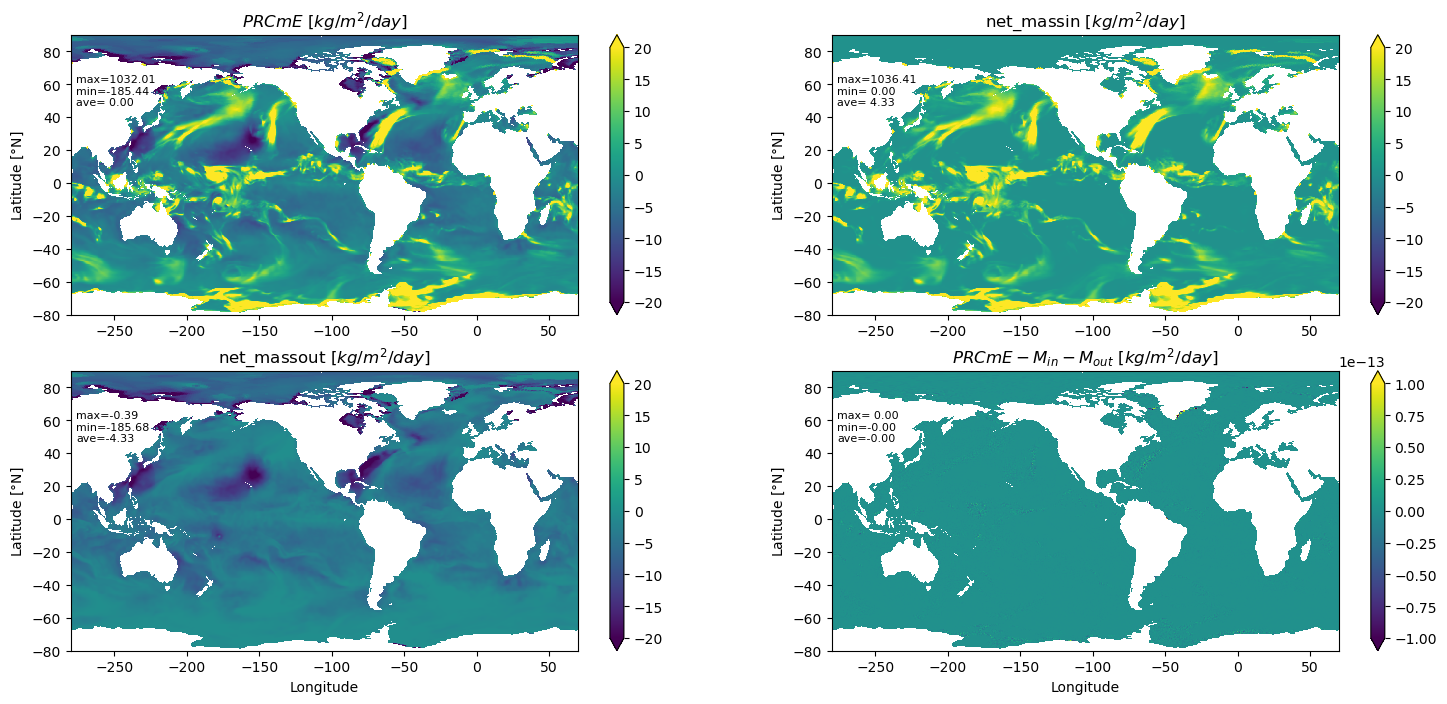

In [25]:
plt.figure(figsize=(18, 8))
newSP(2, 2)

field = 86400.0 * PRCmE
make_plot(lon, lat, field, '$PRCmE$ [$kg/m^2/day$]', cmin=-20, cmax=20)
plt.xlabel('')

nextSP()
field = 86400.0 * net_massin
make_plot(lon, lat, field, 'net_massin [$kg/m^2/day$]', cmin=-20, cmax=20)
plt.xlabel('')

nextSP()
field = 86400.0 * net_massout
make_plot(lon, lat, field, 'net_massout [$kg/m^2/day$]', cmin=-20, cmax=20, xlabel=True)

nextSP()
field = 86400.0 * (PRCmE - net_massout - net_massin)
make_plot(lon, lat, field, '$PRCmE - M_{in} - M_{out}$ [$kg/m^2/day$]', cmin=-1e-13, cmax=1e-13, xlabel=True)

<h2 align="center">Surface mass fluxes II: component fields</h2>

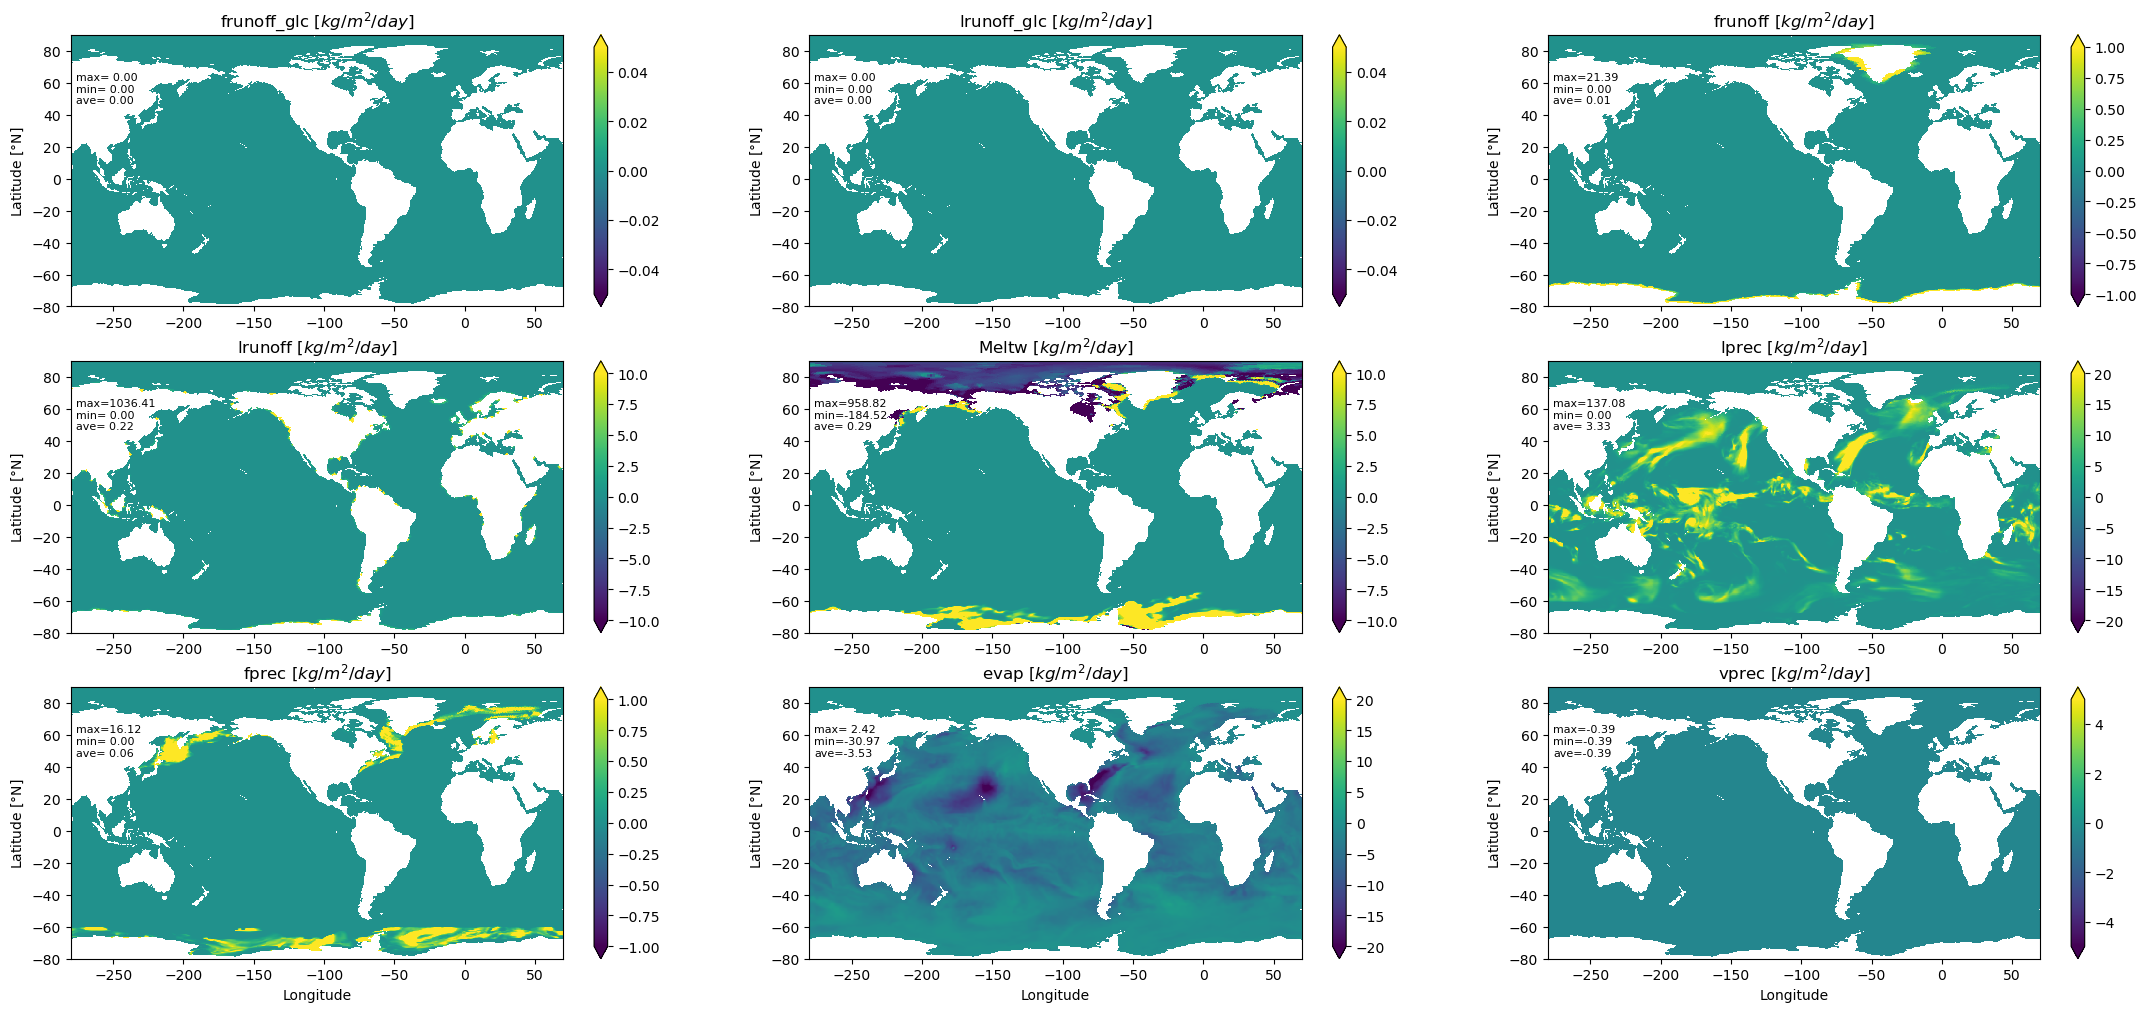

In [28]:
plt.figure(figsize=(27, 12))
newSP(3, 3)

field = 86400.0 * frunoff_glc
make_plot(lon, lat, field, 'frunoff_glc [$kg/m^2/day$]', cmin=0, cmax=0, xlabel=True)
plt.xlabel('')

nextSP()
field = 86400.0 * lrunoff_glc
make_plot(lon, lat, field, 'lrunoff_glc [$kg/m^2/day$]', cmin=0, cmax=0, xlabel=True)
plt.xlabel('')

nextSP()
field = 86400.0 * frunoff
make_plot(lon, lat, field, 'frunoff [$kg/m^2/day$]', cmin=-1, cmax=1, xlabel=True)
plt.xlabel('')

nextSP()
field = 86400.0 * lrunoff
make_plot(lon, lat, field, 'lrunoff [$kg/m^2/day$]', cmin=-10, cmax=10, xlabel=True)
plt.xlabel('')

nextSP()
field = 86400.0 * meltw
make_plot(lon, lat, field, 'Meltw [$kg/m^2/day$]', cmin=-10, cmax=10, xlabel=True)
plt.xlabel('')

nextSP()
# lprec contains a contribution from sea ice melt/formation.
field = 86400.0 * lprec
make_plot(lon, lat, field, 'lprec [$kg/m^2/day$]', cmin=-20, cmax=20, xlabel=True)
plt.xlabel('')

nextSP()
field = 86400.0 * fprec
make_plot(lon, lat, field, 'fprec [$kg/m^2/day$]', cmin=-1, cmax=1, xlabel=True)

nextSP()
# evaporation and condensation
field = 86400.0 * evap
make_plot(lon, lat, field, 'evap [$kg/m^2/day$]', cmin=-20, cmax=20, xlabel=True)

nextSP()
field = 86400.0 * vprec
make_plot(lon, lat, field, 'vprec [$kg/m^2/day$]', cmin=-5, cmax=5, xlabel=True)

<h2 align="center">Surface mass flux self-consistency check</h2>

We will now check if PRCmE = lprec + fprec + lrunoff + frunoff + vprec + evap + meltw + frunoff_glc + lrunoff_glc

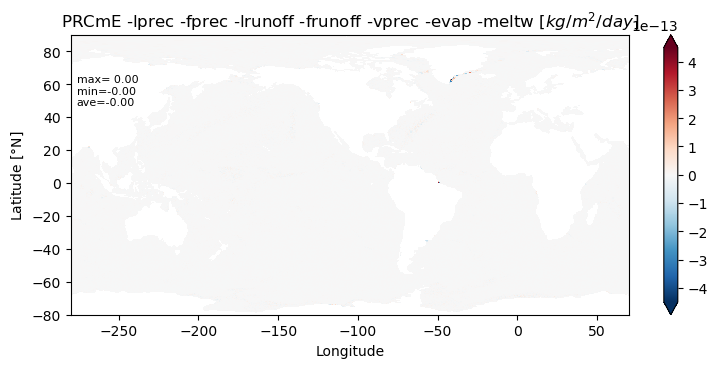

In [39]:
plt.figure(figsize=(9, 8))
newSP(2, 1)
# this should be within "truncation error" precision
field = 86400.0 * (PRCmE - lprec - fprec - lrunoff - frunoff - vprec - evap - meltw - frunoff_glc - lrunoff_glc)
make_plot(lon, lat, field, 'PRCmE -lprec -fprec -lrunoff -frunoff -vprec -evap -meltw [$kg/m^2/day$]', cmin=0.0, cmax=0.0, xlabel=True)


<hr --- />

<h1 align="center">Heat fluxes and global ocean heat budget</h1>

<h2 align="center">Global heat budget consistency check</h2>

We compute the change in seawater heat content over a given time period.  Two different methods are used, and the two methods should agree at the level of truncation error.  If larger differences exist, then there is a bug.

The net heat per time (units of Watts) entering through the ocean boundaries is given by the area integral
$$\begin{equation*}
\mbox{boundary heating of liquid seawater} = \int Q \, dA,
\end{equation*}$$
where the net heat flux (units of $\mbox{W}~\mbox{m}^{-2}~\mbox{s}^{-1}$) is given by 
$$\begin{align*}
 Q &= {\tt (net\_heat\_coupler + heat\_pme + frazil) + internal\_heat + heat\_restore} \\
   &= {\tt net\_heat\_surface + internal\_heat + heat\_restore}
\end{align*}$$
The time change of liquid seawater heat is computed according to 
$$\begin{equation*}
\mbox{seawater heat content change} = 
\frac{C_p }{\tau_{n+1} - \tau_{n} } \int dA \left(\rho_0 \int (\Theta_{n+1} - \Theta_{n}) \, \mathrm{d}z \right) 
\end{equation*}$$
 where $\tau_{n+1} - \tau_{n}$ is the time increment in seconds.  Note that we make use of the MOM6 diagnostic for depth integrated potential/conservative temperature  
$$\begin{equation*}
 {\tt tomint} = \rho_0 \int \Theta \, \mathrm{d}z,
\end{equation*}$$
 where the Boussinesq reference density, $\rho_{0}$, is used since this test case makes the Boussinesq approximation. For self-consistency, we should have the following equality holding to within truncation error  
$$\begin{equation*}
\boxed{
 \mbox{boundary heating of liquid seawater} = \mbox{seawater heat content change}.
}
\end{equation*}$$

In [30]:
n0      = n - 1
dtomint = tomint.isel(time=n) - tomint.isel(time=n0)
dt      = time[n] - time[n0]
lhs     = cp * area * dtomint / dt
rhs     = area * (net_heat_coupler + heat_pme + frazil)

print('Total seawater heat at time step n  [Joules]   =', float(cp * (area * tomint.isel(time=n)).sum()))
print('Total seawater heat at time step n0 [Joules]   =', float(cp * (area * tomint.isel(time=n0)).sum()))
print('Total seawater heat content change [Joules]    =', float(dt * lhs.sum()))
print('Net heat through boundaries [Joules]           =', float(dt * rhs.sum()))
print('Residual [Joules]                              =', float(dt * lhs.sum() - dt * rhs.sum()))
print('Non-dimensional residual (based on difference) =', float((lhs.sum() - rhs.sum()) / lhs.sum()))
print('Non-dimensional residual (based on tomint[n])  =', float((lhs.sum() - rhs.sum()) / (cp * (area * tomint.isel(time=n)).sum())))

Total seawater heat at time step n  [Joules]   = 1.991266151962276e+25
Total seawater heat at time step n0 [Joules]   = 1.9912403096544068e+25
Total seawater heat content change [Joules]    = 2.5842307869582826e+20
Net heat through boundaries [Joules]           = 2.554715181878263e+20
Residual [Joules]                              = 2.9515605080019436e+18
Non-dimensional residual (based on difference) = 0.011421427694838362
Non-dimensional residual (based on tomint[n])  = 1.7155707648654483e-12


<h2 align="center">Basic components to surface heat flux</h2> 

Self-consistency check: net_heat_surface = heat_pme + frazil + net_heat_coupler 

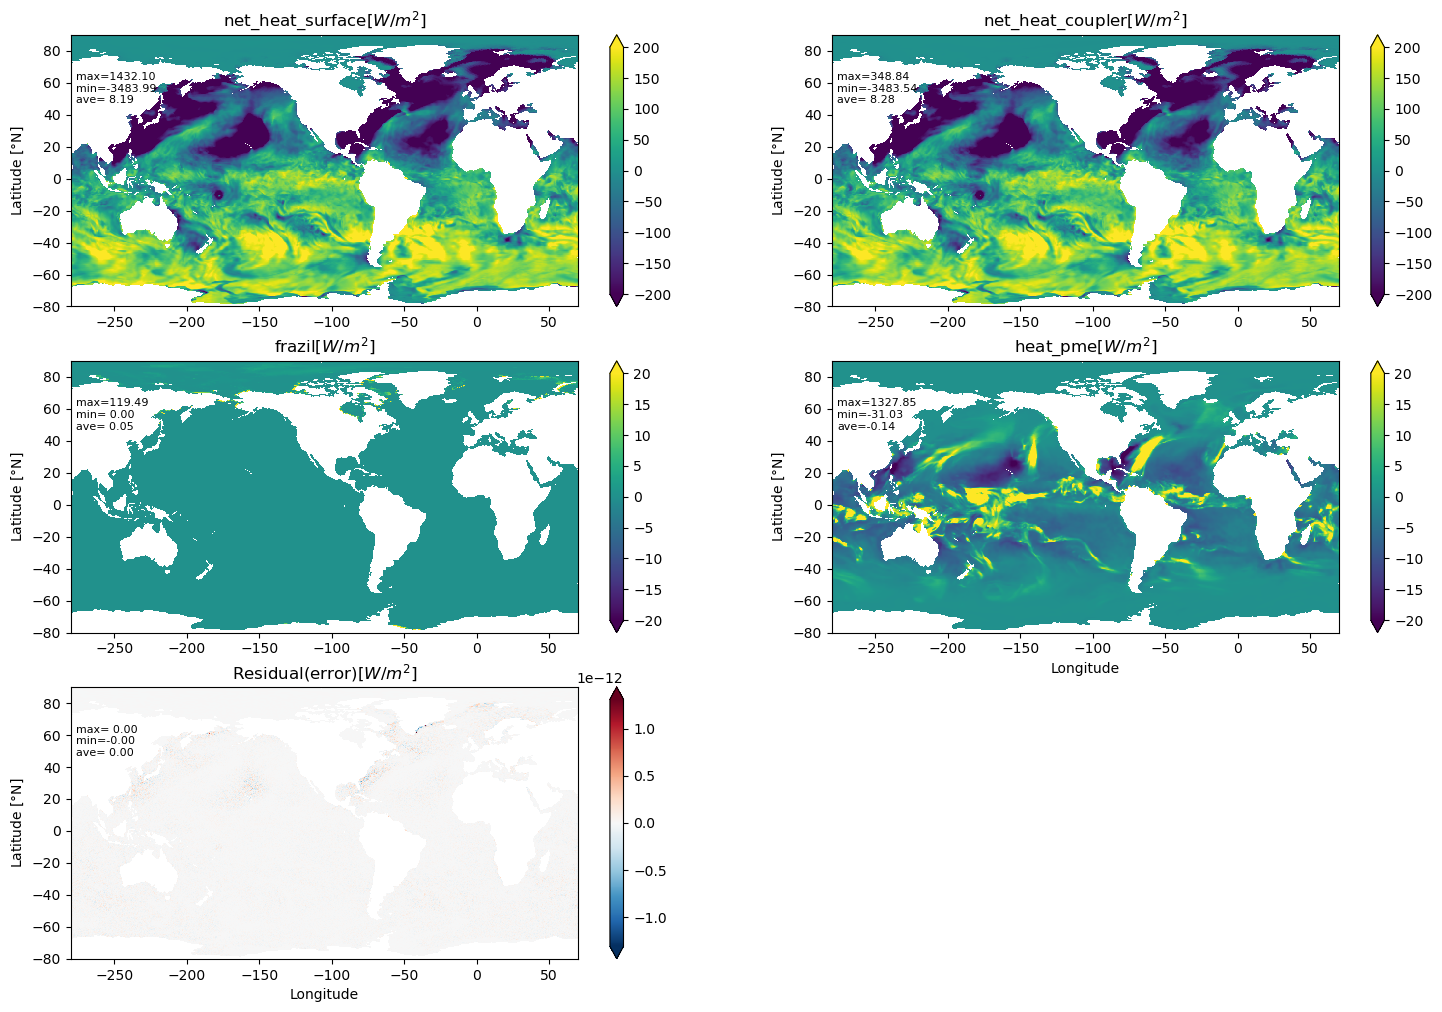

In [33]:
plt.figure(figsize=(18, 12))
newSP(3, 2)

field = net_heat_surface
make_plot(lon, lat, field, 'net_heat_surface[$W/m^2$]')
plt.xlabel('')

nextSP()
field = net_heat_coupler
make_plot(lon, lat, field, 'net_heat_coupler[$W/m^2$]')
plt.xlabel('')

nextSP()
field = frazil
make_plot(lon, lat, field, 'frazil[$W/m^2$]', cmin=-20, cmax=20)
plt.xlabel('')

nextSP()
field = heat_pme
make_plot(lon, lat, field, 'heat_pme[$W/m^2$]', cmin=-20, cmax=20, xlabel=True)

nextSP()
field = net_heat_surface - net_heat_coupler - frazil - heat_pme
make_plot(lon, lat, field, 'Residual(error)[$W/m^2$]', cmin=0.0, cmax=0.0, xlabel=True)

<h2 align="center">Heat fluxes crossing ocean surface via the coupler</h2> 

Heat fluxes crossing ocean surface via the coupler: net_heat_coupler = LwLatSens + SW + melth, where LwLatSens = LW + Latent + Sensible

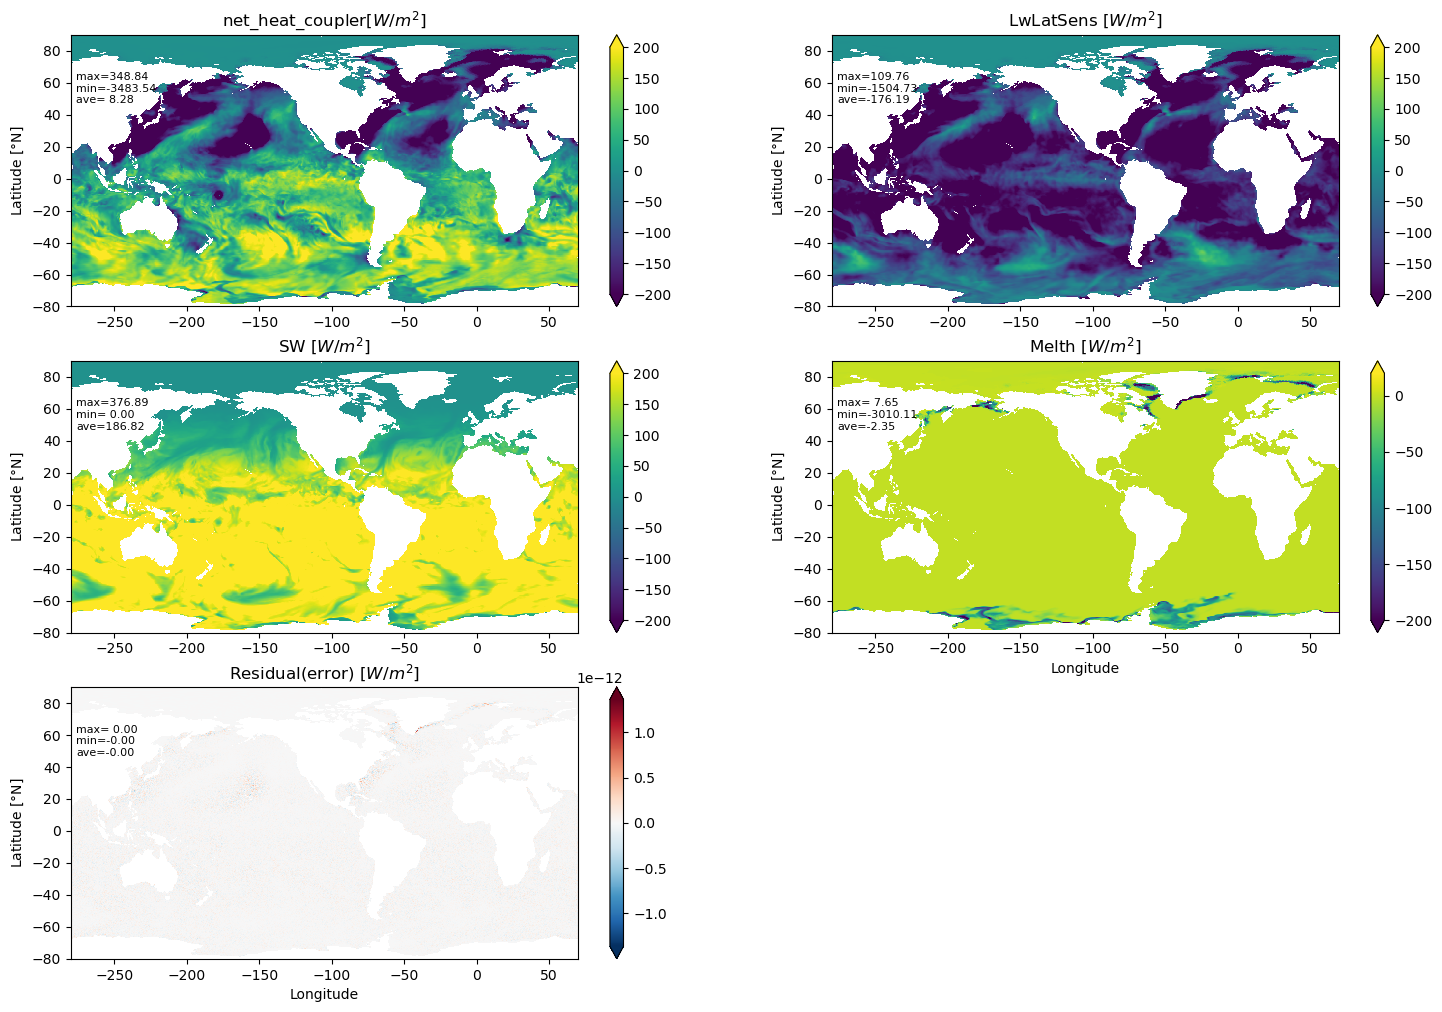

In [34]:
plt.figure(figsize=(18, 12))
newSP(3, 2)

field = net_heat_coupler
make_plot(lon, lat, field, 'net_heat_coupler[$W/m^2$]', cmin=-200, cmax=200)
plt.xlabel('')

nextSP()
field = LwLatSens
make_plot(lon, lat, field, 'LwLatSens [$W/m^2$]', cmin=-200, cmax=200)
plt.xlabel('')

nextSP()
field = SW
make_plot(lon, lat, field, 'SW [$W/m^2$]', cmin=-200, cmax=200)
plt.xlabel('')

nextSP()
field = melth
make_plot(lon, lat, field, 'Melth [$W/m^2$]', cmin=-200, cmax=20, xlabel=True)

nextSP()
field = net_heat_coupler - SW - LwLatSens - melth
make_plot(lon, lat, field, 'Residual(error) [$W/m^2$]', cmin=0.0, cmax=0.0, xlabel=True)

<h2 align="center">Components of heat content from surface mass fluxes</h2>

Components of heat content of surface mass fluxes: heat_PmE = heat_content_lprec + heat_content_fprec + heat_content_vprec + heat_content_lrunoff + heat_content_frunoff +heat_content_meltw + heat_content_cond + heat_content_massout + heat_content_frunoff_glc + heat_content_lrunoff_glc

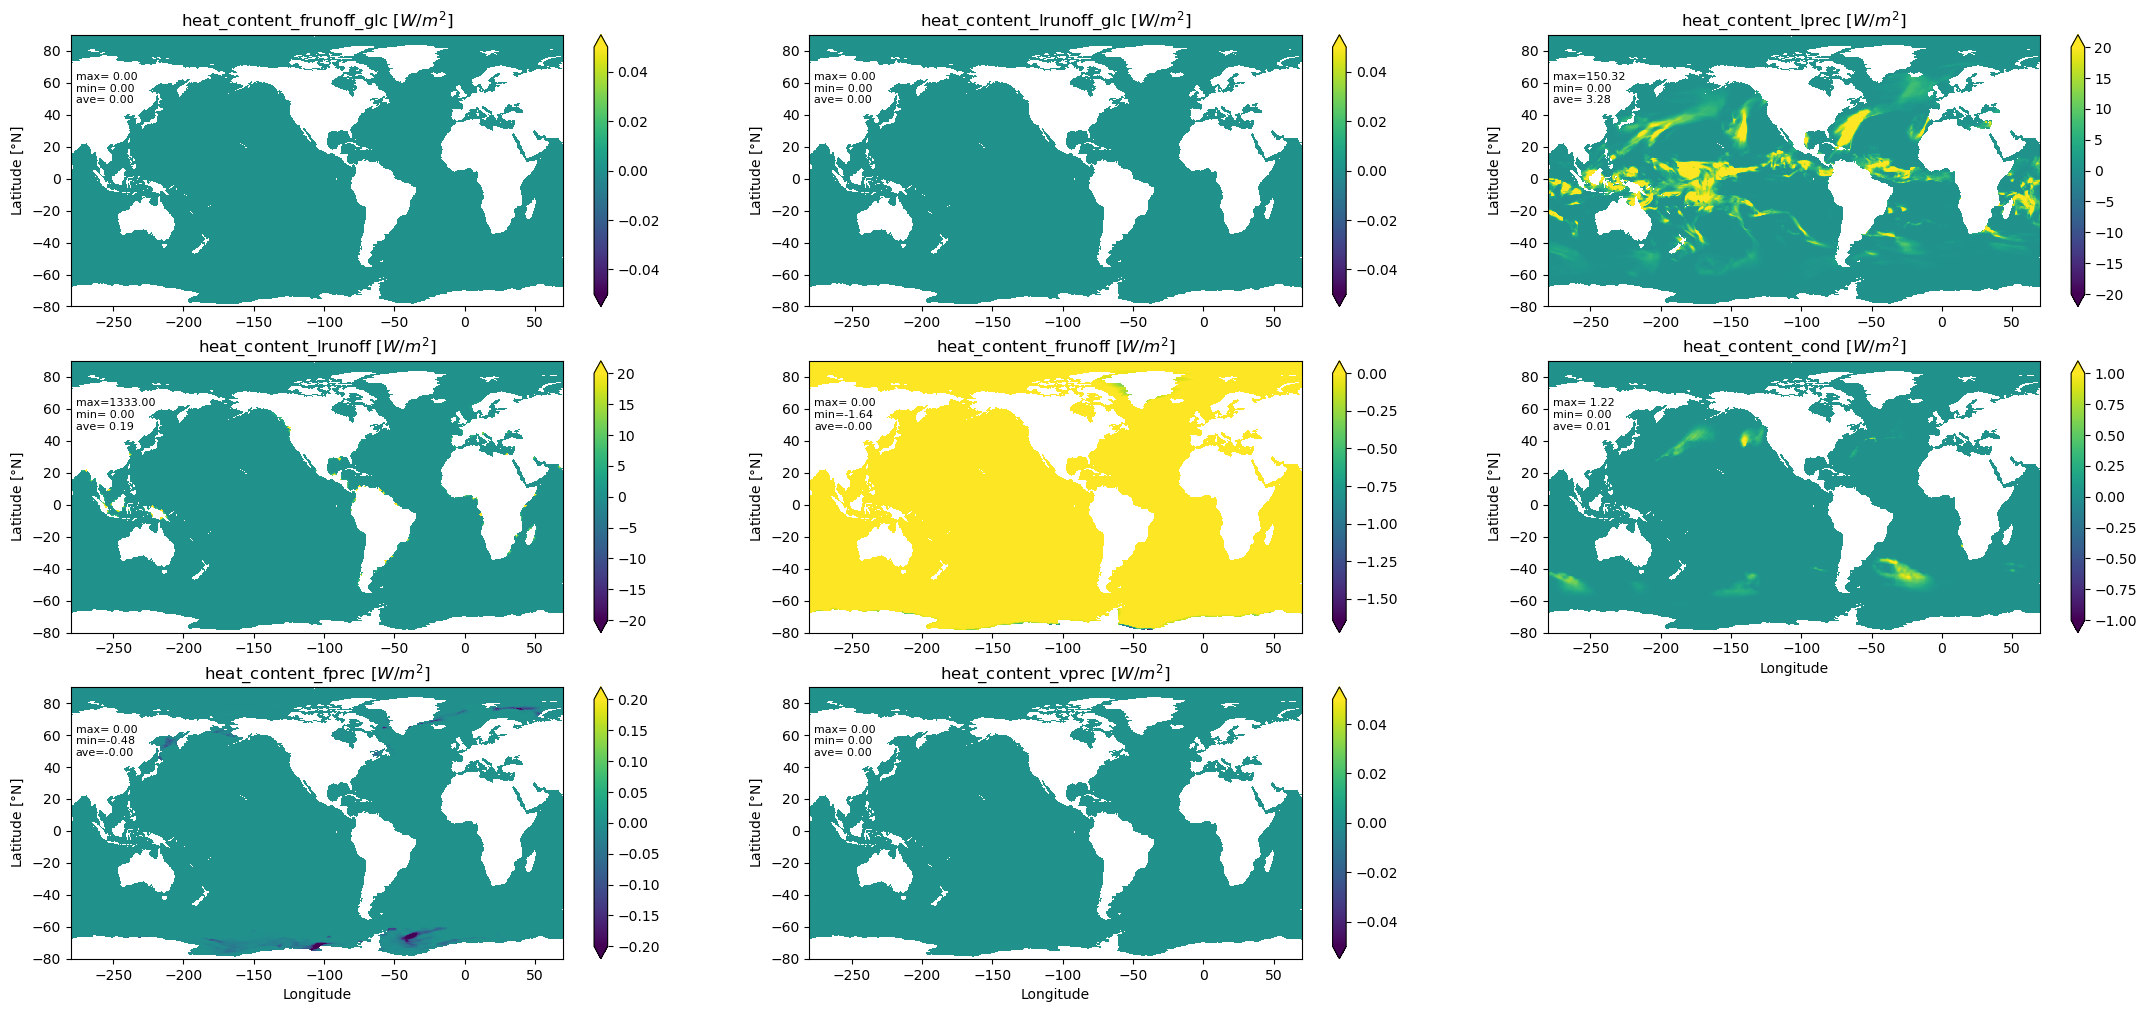

In [35]:
plt.figure(figsize=(27, 12))
newSP(3, 3)

field = heat_content_frunoff_glc
make_plot(lon, lat, field, 'heat_content_frunoff_glc [$W/m^2$]', cmin=-0.0, cmax=0.0)
plt.xlabel('')

nextSP()
field = heat_content_lrunoff_glc
make_plot(lon, lat, field, 'heat_content_lrunoff_glc [$W/m^2$]', cmin=0.0, cmax=0.0)
plt.xlabel('')

nextSP()
field = heat_content_lprec
make_plot(lon, lat, field, 'heat_content_lprec [$W/m^2$]', cmin=-20.0, cmax=20.0)
plt.xlabel('')

nextSP()
field = heat_content_lrunoff
make_plot(lon, lat, field, 'heat_content_lrunoff [$W/m^2$]', cmin=-20.0, cmax=20.0)
plt.xlabel('')

nextSP()
field = heat_content_frunoff
make_plot(lon, lat, field, 'heat_content_frunoff [$W/m^2$]', cmin=0.0, cmax=0.0)
plt.xlabel('')

nextSP()
field = heat_content_cond
make_plot(lon, lat, field, 'heat_content_cond [$W/m^2$]', cmin=-1.0, cmax=1.0, xlabel=True)

nextSP()
field = heat_content_fprec
make_plot(lon, lat, field, 'heat_content_fprec [$W/m^2$]', cmin=-0.2, cmax=0.2, xlabel=True)

nextSP()
field = heat_content_vprec
make_plot(lon, lat, field, 'heat_content_vprec [$W/m^2$]', cmin=-0.0, cmax=.0, xlabel=True)

<h2 align="center">Self-consistency between heat_pme and heat_content_surfwater</h2>

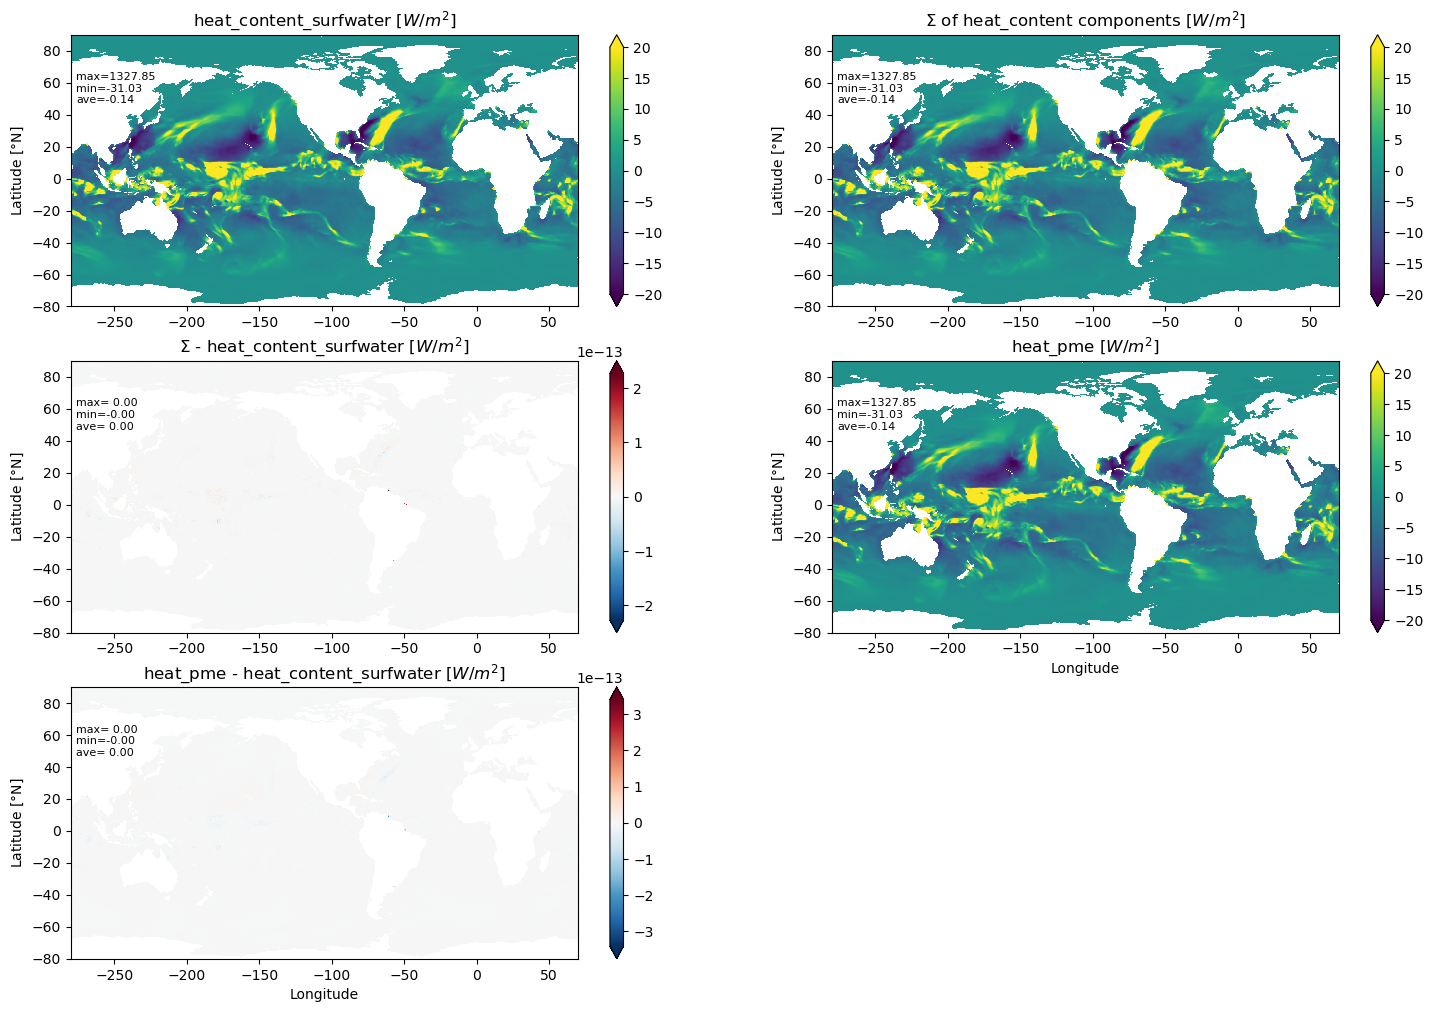

In [36]:
comp_sum = (heat_content_lprec + heat_content_fprec + heat_content_vprec
            + heat_content_frunoff + heat_content_cond + heat_content_evap
            + heat_content_lrunoff + heat_content_lrunoff_glc + heat_content_frunoff_glc)

plt.figure(figsize=(18, 12))
newSP(3, 2)

field = heat_content_surfwater
make_plot(lon, lat, field, 'heat_content_surfwater [$W/m^2$]', cmin=-20.0, cmax=20.0)
plt.xlabel('')

nextSP()
field = comp_sum
make_plot(lon, lat, field, '$\\Sigma$ of heat_content components [$W/m^2$]', cmin=-20.0, cmax=20.0)
plt.xlabel('')

nextSP()
# this should be within "truncation error" precision
field = comp_sum - heat_content_surfwater
make_plot(lon, lat, field, '$\\Sigma$ - heat_content_surfwater [$W/m^2$]', cmin=0.0, cmax=0.0)
plt.xlabel('')

nextSP()
field = heat_pme
make_plot(lon, lat, field, 'heat_pme [$W/m^2$]', cmin=-20.0, cmax=20.0, xlabel=True)

nextSP()
# this should be within "truncation error" precision
field = heat_pme - heat_content_surfwater
make_plot(lon, lat, field, 'heat_pme - heat_content_surfwater [$W/m^2$]', cmin=0.0, cmax=0.0, xlabel=True)


<hr --- />

<h1 align="center">Salt fluxes and global ocean salt budget</h1>

<h2 align="center">Global salt budget consistency check</h2>

We compute the change in seawater salt content over a given time period.  Two different methods are used, and the two methods should agree at the level of truncation error.  If larger differences exist, then there is a bug.

The net salt per time (units of kg/s) entering through the ocean boundaries is given by the area integral
$$\begin{equation*}
\mbox{boundary salt entering liquid seawater} = \int Q_{S} \, dA,
\end{equation*}$$
where the net salt flux (units of $\mbox{kg}~\mbox{m}^{-2}~\mbox{s}^{-1}$) is given by 
$$\begin{align*}
 Q_{S} &= {\tt salt\_flux} + {\tt salt\_restore}.
\end{align*}$$
A nonzero salt flux is associated with exchanges between liquid seawater and solid sea ice.  It also arises from simulations using a restoring boundary flux associated with damping to observed sea surface salinity.  Finally, there can be a salt flux when using sponges to damp the ocean interior back to an observed value.  

The time change of liquid seawater salt content is computed according to 
$$\begin{equation*}
\mbox{seawater salt content change} = 
\frac{1}{\tau_{n+1} - \tau_{n} } \int dA \left(\rho_0 \int (S_{n+1} - S_{n}) \, \mathrm{d}z \right) 
\end{equation*}$$
where $\tau_{n+1} - \tau_{n}$ is the time increment in seconds.  Note that we make use of the MOM6 diagnostic for depth integrated salinity 
$$\begin{equation*}
 {\tt somint} = \rho_0 \int S \, \mathrm{d}z,
\end{equation*}$$
where the Boussinesq reference density, $\rho_{0}$, is used since this test case makes the Boussinesq approximation. For self-consistency, we should have the following equality holding to within truncation error  
$$\begin{equation*}
\boxed{
 \mbox{boundary salt entering liquid seawater} = \mbox{seawater salt content change}.
}
\end{equation*}$$

In [17]:
n0      = n - 1
dsomint = somint.isel(time=n) - somint.isel(time=n0)
dt      = time[n] - time[n0]
lhs     = 1.e-3 * area * dsomint / dt
rhs     = area * (salt_flux + salt_restore)

print('Total seawater salt at time step n  [kg salt]    =', float((area * somint.isel(time=n)).sum()))
print('Total seawater salt at time step n0 [kg salt]    =', float((area * somint.isel(time=n0)).sum()))
print('Total seawater salt content change [kg salt]     =', float(dt * lhs.sum()))
print('Net salt through boundaries [kg salt]            =', float(dt * rhs.sum()))
print('Residual [kg salt]                               =', float(dt * lhs.sum() - dt * rhs.sum()))
print('Non-dimensional residual (based on diference)    =', float((lhs.sum() - rhs.sum()) / lhs.sum()))
print('Non-dimensional residual (based on somint[n])    =', float((lhs.sum() - rhs.sum()) / (area * somint.isel(time=n)).sum()))

Total seawater salt at time step n  [kg salt]    = 4.805001878965925e+22
Total seawater salt at time step n0 [kg salt]    = 4.805001851750787e+22
Total seawater salt content change [kg salt]     = 272151386136.557
Net salt through boundaries [kg salt]            = 272151386028.0011
Residual [kg salt]                               = 108.555908203125
Non-dimensional residual (based on diference)    = 3.9888063945958045e-10
Non-dimensional residual (based on somint[n])    = 2.6148465256544127e-26


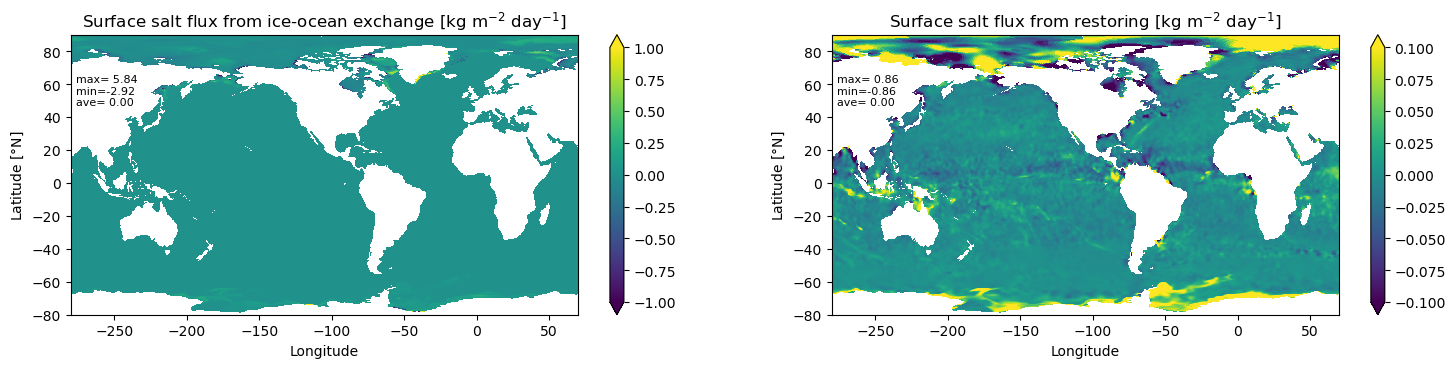

In [38]:
plt.figure(figsize=(18, 8))
newSP(2, 2)

field = 86400.0 * salt_flux
make_plot(lon, lat, field, 'Surface salt flux from ice-ocean exchange [kg m$^{-2}$ day$^{-1}$]', cmin=-1.0, cmax=1.0, xlabel=True)

nextSP()
field = 86400.0 * salt_restore
make_plot(lon, lat, field, 'Surface salt flux from restoring [kg m$^{-2}$ day$^{-1}$]', cmin=-0.1, cmax=0.1, xlabel=True)